# BIG Money — Exploratory Data Analysis
**Orange County Housing Market Flight Risk Analysis**  
Datathon @ Data @ UCI | 767K properties across 85 ZIP codes


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100


## 1. Load the Data

In [2]:
avm = pd.read_csv("AVM.csv")
migration = pd.read_csv("OC2025_ZIPMigration.csv")
user_inputs = pd.read_csv("oc_user_inputs_clean.csv")
flight_risk = pd.read_csv("zip_flight_risk_scores.csv")

print(f"AVM:            {avm.shape[0]:>10,} rows × {avm.shape[1]} cols")
print(f"Migration:      {migration.shape[0]:>10,} rows × {migration.shape[1]} cols")
print(f"User Inputs:    {user_inputs.shape[0]:>10,} rows × {user_inputs.shape[1]} cols")
print(f"Flight Risk:    {flight_risk.shape[0]:>10,} rows × {flight_risk.shape[1]} cols")


AVM:               767,204 rows × 14 cols
Migration:              85 rows × 10 cols
User Inputs:            85 rows × 5 cols
Flight Risk:            85 rows × 11 cols


## 2. AVM Dataset Overview

In [3]:
avm.head()

,RecordId,FIPSCode,County,Address,City,State,ZipCode,ZipCodePlus4,Latitude,Longitude,FinalValue,HighValue,LowValue,ValuationDate
0,1,6059,Orange,1706 English St,Santa Ana,CA,92706,2336,33.760395,-117.896982,807000.0,851000.0,765000.0,20260128
1,2,6059,Orange,1710 English St,Santa Ana,CA,92706,2336,33.760395,-117.896982,861000.0,908000.0,816000.0,20260128
2,3,6059,Orange,1714 English St,Santa Ana,CA,92706,2336,33.760395,-117.896982,799000.0,846000.0,755000.0,20260128
3,4,6059,Orange,1718 English St,Santa Ana,CA,92706,2336,33.760395,-117.896982,818000.0,886000.0,755000.0,20260128
4,5,6059,Orange,1802 English St,Santa Ana,CA,92706,2338,33.761306,-117.896644,996000.0,1049000.0,945000.0,20260128


In [4]:
avm.describe()

,RecordId,FIPSCode,ZipCode,ZipCodePlus4,Latitude,Longitude,FinalValue,HighValue,LowValue,ValuationDate
count,767204.000000,767204.0,767204.000000,767204.000000,767204.000000,767204.000000,7.672040e+05,7.672040e+05,7.672040e+05,767204.0
mean,394843.912087,6059.0,92536.897717,3760.301517,33.716876,-117.840289,1.469389e+06,1.557031e+06,1.386939e+06,20260128.0
std,232488.397232,0.0,588.838052,2002.327118,0.120080,0.130074,1.046178e+06,1.121787e+06,9.791101e+05,0.0
min,1.000000,6059.0,90620.000000,2.000000,33.389987,-121.923738,4.300000e+04,4.600000e+04,4.000000e+04,20260128.0
25%,194832.750000,6059.0,92630.000000,2135.000000,33.637663,-117.950036,9.170000e+05,9.700000e+05,8.660000e+05,20260128.0
50%,388676.500000,6059.0,92679.000000,3412.000000,33.719692,-117.850799,1.216000e+06,1.287000e+06,1.149000e+06,20260128.0
75%,584288.250000,6059.0,92804.000000,5101.000000,33.812615,-117.734688,1.646000e+06,1.741000e+06,1.555000e+06,20260128.0
max,803037.000000,6059.0,95124.000000,9874.000000,37.255499,-117.426830,9.999000e+06,1.224600e+07,9.474000e+06,20260128.0


In [5]:
# Check for nulls
avm.isnull().sum()

RecordId         0
FIPSCode         0
County           0
Address          0
City             0
State            0
ZipCode          0
ZipCodePlus4     0
Latitude         0
Longitude        0
FinalValue       0
HighValue        0
LowValue         0
ValuationDate    0
dtype: int64

## 3. Property Value Distribution

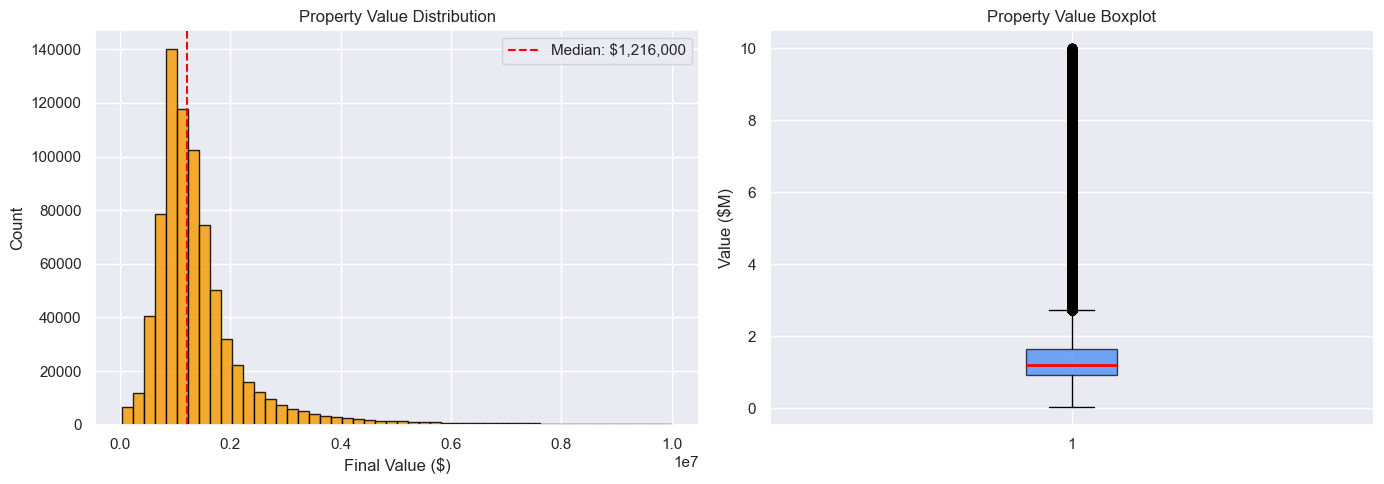

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(avm['FinalValue'], bins=50, color='#f59e0b', edgecolor='black', alpha=0.85)
axes[0].set_xlabel('Final Value ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Property Value Distribution')
axes[0].axvline(avm['FinalValue'].median(), color='red', linestyle='--', label=f"Median: ${avm['FinalValue'].median():,.0f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(avm['FinalValue'] / 1e6, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3b82f6', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Value ($M)')
axes[1].set_title('Property Value Boxplot')

plt.tight_layout()
plt.show()


## 4. Property Values by City

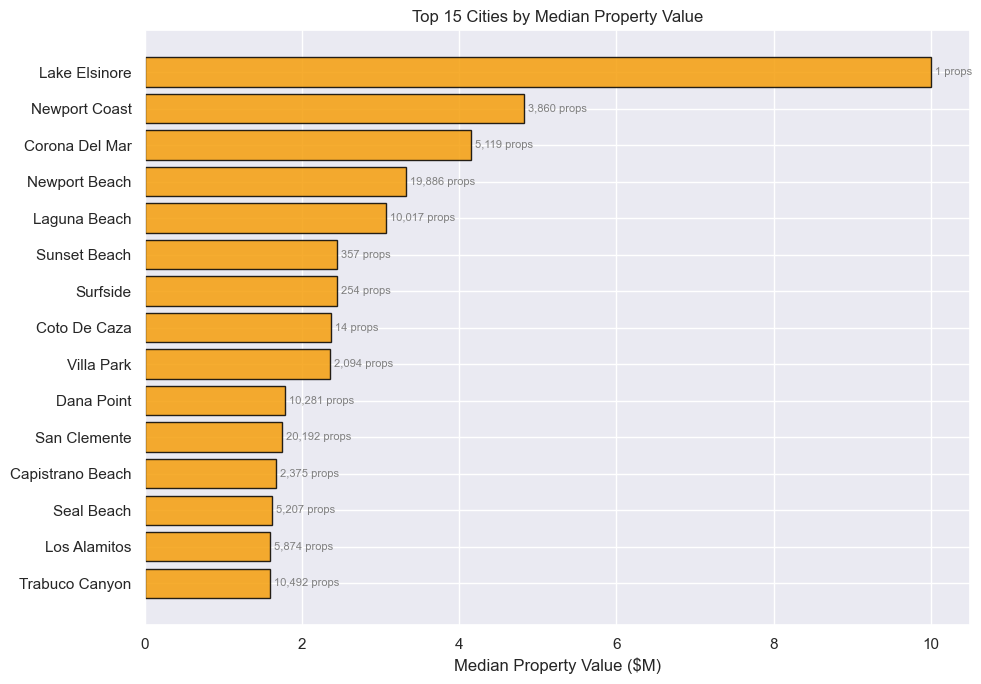

In [7]:
city_stats = avm.groupby('City')['FinalValue'].agg(['median', 'count']).sort_values('median', ascending=True)

top15 = city_stats.tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15.index, top15['median'] / 1e6, color='#f59e0b', edgecolor='black', alpha=0.85)
ax.set_xlabel('Median Property Value ($M)')
ax.set_title('Top 15 Cities by Median Property Value')

for bar, count in zip(bars, top15['count']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{count:,} props', va='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()


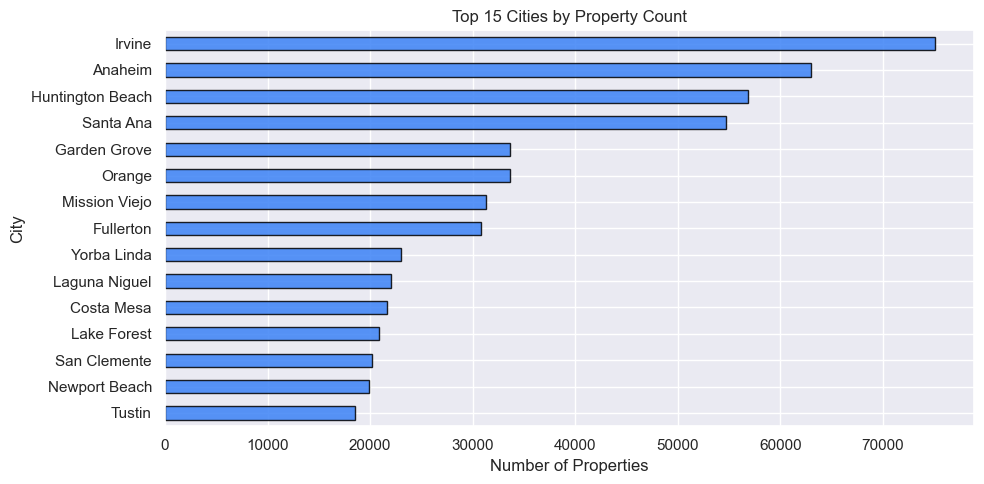

In [8]:
top_cities = avm['City'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_cities.sort_values().plot(kind='barh', ax=ax, color='#3b82f6', edgecolor='black', alpha=0.85)
ax.set_xlabel('Number of Properties')
ax.set_title('Top 15 Cities by Property Count')
plt.tight_layout()
plt.show()


## 5. Migration Analysis

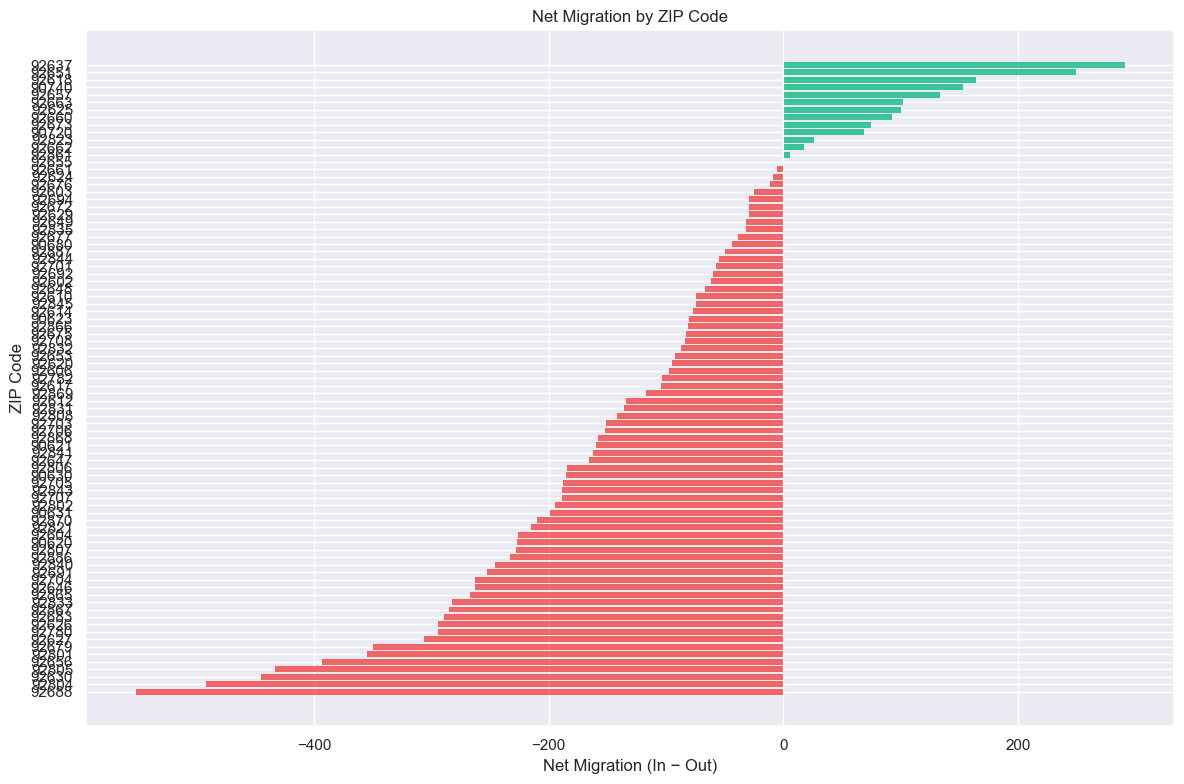

In [9]:
migration['NetFlow'] = migration['MovesIntoZip'] - migration['MovesOutOfZip']
migration_sorted = migration.sort_values('NetFlow')

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#ef4444' if x < 0 else '#10b981' for x in migration_sorted['NetFlow']]
ax.barh(migration_sorted['ZipCode'].astype(str), migration_sorted['NetFlow'], color=colors, edgecolor='none', alpha=0.8)
ax.set_xlabel('Net Migration (In − Out)')
ax.set_title('Net Migration by ZIP Code')
ax.axvline(0, color='white', linewidth=0.8)
ax.set_ylabel('ZIP Code')
plt.tight_layout()
plt.show()


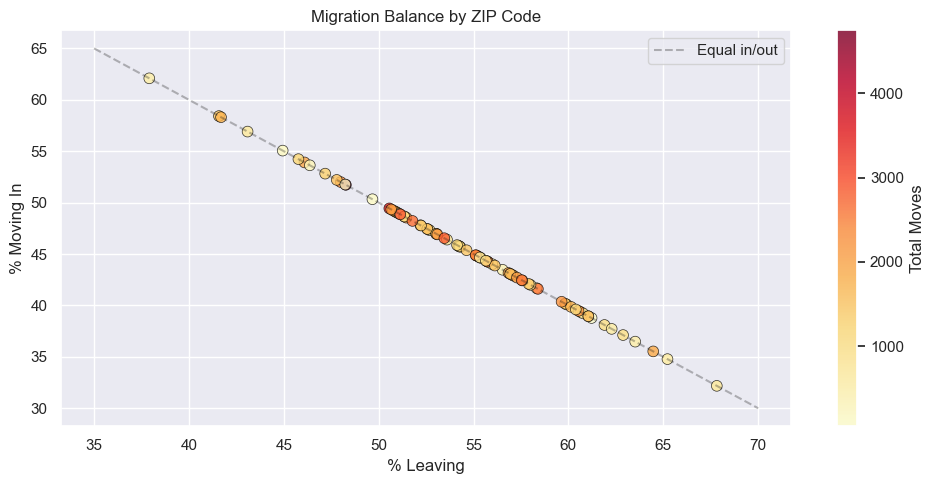

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(migration['PctLeave'], migration['PctMoveIn'], 
           c=migration['TotalMoves'], cmap='YlOrRd', s=60, edgecolors='black', linewidth=0.5, alpha=0.8)
ax.plot([35, 70], [65, 30], 'k--', alpha=0.3, label='Equal in/out')
ax.set_xlabel('% Leaving')
ax.set_ylabel('% Moving In')
ax.set_title('Migration Balance by ZIP Code')
plt.colorbar(ax.collections[0], label='Total Moves')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Flight Risk Scores

In [11]:
flight_risk.head(10)

,ZipCode,flight_risk_score,risk_tier,pct_leave,net_migration_rate,price_spread_pct,turnover_rate,median_value,property_count,ZipCode_Latitude,ZipCode_Longitude
0,92865,0.743944,High,0.6782,0.356475,0.112523,0.138678,1102000.0,5401,33.8290,-117.8463
1,92676,0.697660,High,0.6122,0.224490,0.134368,0.080328,1127500.0,610,33.7172,-117.6427
2,92843,0.662477,Medium,0.6522,0.304348,0.111562,0.085785,986000.0,7239,33.7645,-117.9324
3,92688,0.662276,Medium,0.6447,0.289308,0.111517,0.147632,1094000.0,12924,33.6369,-117.6043
4,92617,0.641882,Medium,0.5712,0.142466,0.115509,0.599343,770500.0,1218,33.6432,-117.8379
5,92706,0.630412,Medium,0.6352,0.270463,0.112524,0.093387,1062000.0,6018,33.7648,-117.8806
6,92704,0.625419,Medium,0.6288,0.257591,0.115297,0.072960,876000.0,13994,33.7213,-117.9071
7,92703,0.622942,Medium,0.6228,0.245528,0.117216,0.075174,819000.0,8181,33.7485,-117.9054
8,92840,0.598835,Medium,0.6190,0.237911,0.113418,0.097954,987500.0,10556,33.7854,-117.9318
9,92801,0.594284,Medium,0.6014,0.202741,0.114187,0.211040,867000.0,8297,33.8423,-117.9530


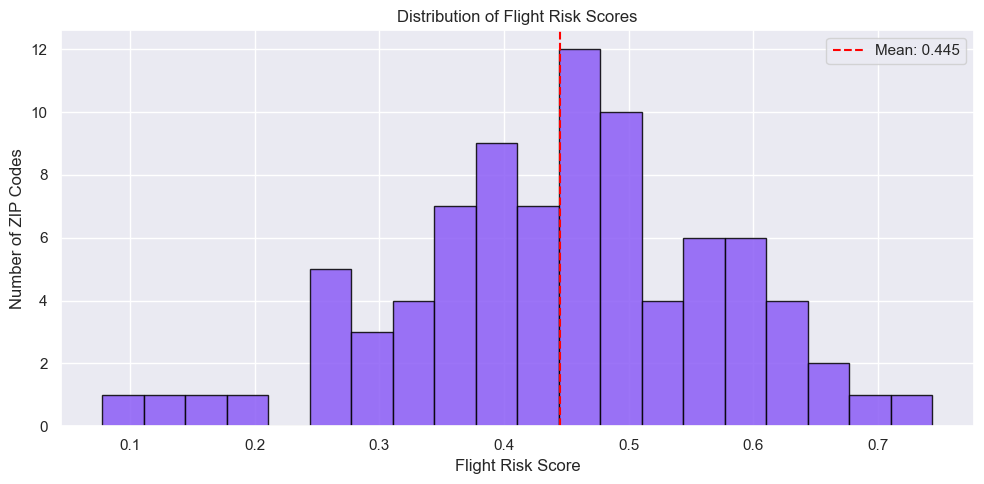

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(flight_risk['flight_risk_score'], bins=20, color='#8b5cf6', edgecolor='black', alpha=0.85)
ax.set_xlabel('Flight Risk Score')
ax.set_ylabel('Number of ZIP Codes')
ax.set_title('Distribution of Flight Risk Scores')
ax.axvline(flight_risk['flight_risk_score'].mean(), color='red', linestyle='--', 
           label=f"Mean: {flight_risk['flight_risk_score'].mean():.3f}")
ax.legend()
plt.tight_layout()
plt.show()


Risk Tier Distribution:
risk_tier
Medium    69
Low       14
High       2
Name: count, dtype: int64



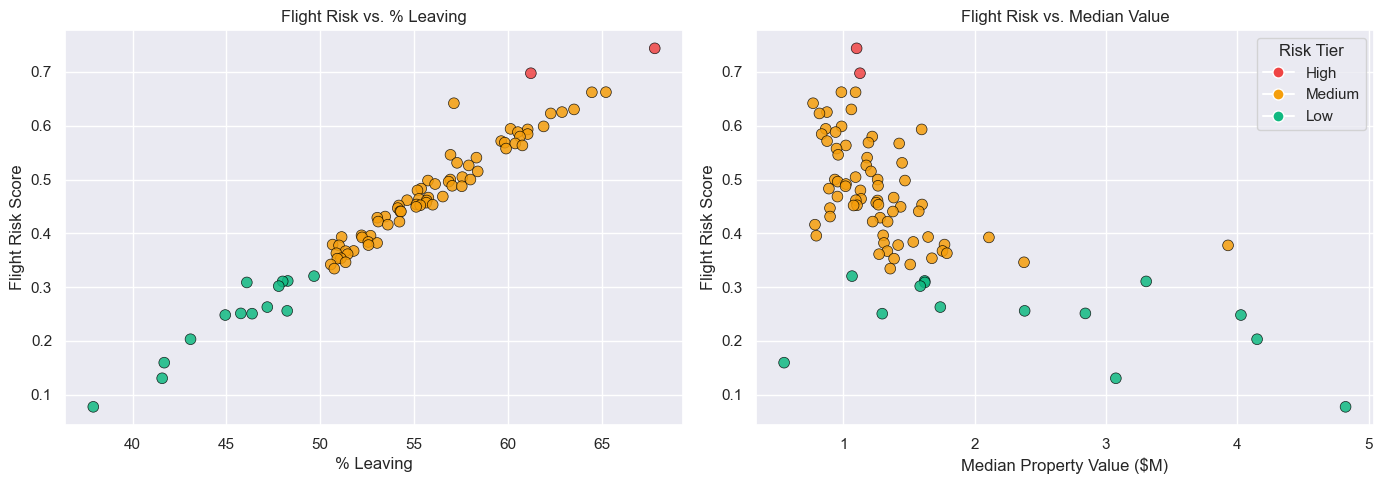

In [13]:
print("Risk Tier Distribution:")
print(flight_risk['risk_tier'].value_counts())
print()

tier_colors = {'High': '#ef4444', 'Medium': '#f59e0b', 'Low': '#10b981'}
color_map = flight_risk['risk_tier'].map(tier_colors)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk vs % leaving
axes[0].scatter(flight_risk['pct_leave'] * 100, flight_risk['flight_risk_score'], 
                c=color_map, s=60, edgecolors='black', linewidth=0.5, alpha=0.85)
axes[0].set_xlabel('% Leaving')
axes[0].set_ylabel('Flight Risk Score')
axes[0].set_title('Flight Risk vs. % Leaving')

# Risk vs median value
axes[1].scatter(flight_risk['median_value'] / 1e6, flight_risk['flight_risk_score'],
                c=color_map, s=60, edgecolors='black', linewidth=0.5, alpha=0.85)
axes[1].set_xlabel('Median Property Value ($M)')
axes[1].set_ylabel('Flight Risk Score')
axes[1].set_title('Flight Risk vs. Median Value')

# Add legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=t) 
                   for t, c in tier_colors.items()]
axes[1].legend(handles=legend_elements, title='Risk Tier')

plt.tight_layout()
plt.show()


In [14]:
top10 = flight_risk.nlargest(10, 'flight_risk_score')[['ZipCode','flight_risk_score','risk_tier','pct_leave','median_value','net_migration_rate','turnover_rate','property_count']]
top10.columns = ['ZIP', 'Risk Score', 'Tier', '% Leave', 'Median Value', 'Net Migration', 'Turnover', 'Properties']
print("Top 10 Highest Flight Risk ZIP Codes:")
top10


Top 10 Highest Flight Risk ZIP Codes:


,ZIP,Risk Score,Tier,% Leave,Median Value,Net Migration,Turnover,Properties
0,92865,0.743944,High,0.6782,1102000.0,0.356475,0.138678,5401
1,92676,0.697660,High,0.6122,1127500.0,0.224490,0.080328,610
2,92843,0.662477,Medium,0.6522,986000.0,0.304348,0.085785,7239
3,92688,0.662276,Medium,0.6447,1094000.0,0.289308,0.147632,12924
4,92617,0.641882,Medium,0.5712,770500.0,0.142466,0.599343,1218
5,92706,0.630412,Medium,0.6352,1062000.0,0.270463,0.093387,6018
6,92704,0.625419,Medium,0.6288,876000.0,0.257591,0.072960,13994
7,92703,0.622942,Medium,0.6228,819000.0,0.245528,0.075174,8181
8,92840,0.598835,Medium,0.6190,987500.0,0.237911,0.097954,10556
9,92801,0.594284,Medium,0.6014,867000.0,0.202741,0.211040,8297


## 7. Feature Correlations

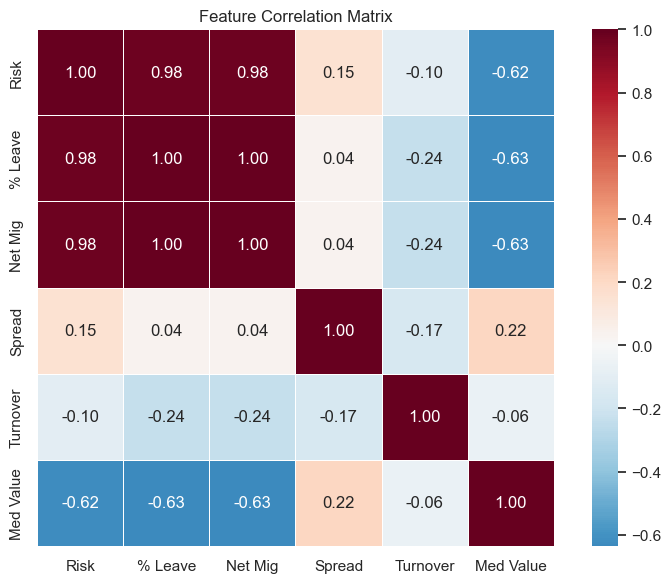

In [15]:
corr_cols = ['flight_risk_score', 'pct_leave', 'net_migration_rate', 'price_spread_pct', 'turnover_rate', 'median_value']
corr = flight_risk[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, ax=ax,
            xticklabels=['Risk', '% Leave', 'Net Mig', 'Spread', 'Turnover', 'Med Value'],
            yticklabels=['Risk', '% Leave', 'Net Mig', 'Spread', 'Turnover', 'Med Value'])
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## 8. Geographic Distribution

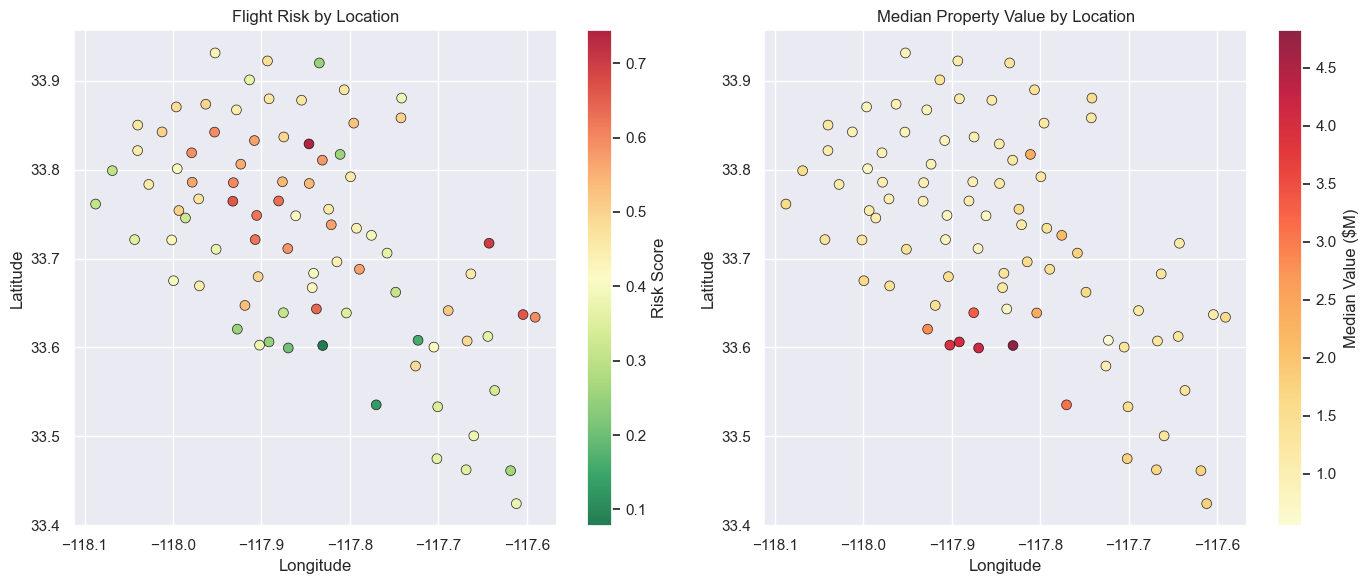

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Map colored by risk score
sc1 = axes[0].scatter(flight_risk['ZipCode_Longitude'], flight_risk['ZipCode_Latitude'],
                       c=flight_risk['flight_risk_score'], cmap='RdYlGn_r', s=50, 
                       edgecolors='black', linewidth=0.5, alpha=0.85)
axes[0].set_title('Flight Risk by Location')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.colorbar(sc1, ax=axes[0], label='Risk Score')

# Map colored by median value
sc2 = axes[1].scatter(flight_risk['ZipCode_Longitude'], flight_risk['ZipCode_Latitude'],
                       c=flight_risk['median_value'] / 1e6, cmap='YlOrRd', s=50,
                       edgecolors='black', linewidth=0.5, alpha=0.85)
axes[1].set_title('Median Property Value by Location')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(sc2, ax=axes[1], label='Median Value ($M)')

plt.tight_layout()
plt.show()


## 9. Key Takeaways

- **767,204 properties** across **85 ZIP codes** in Orange County, with **zero missing values**
- Median property value is **$1.22M**, with a right-skewed distribution ranging from $43K to $10M
- Only **2 ZIP codes** (92865, 92676) are classified as **High Risk** — most are Medium (69)
- **% leaving** is the strongest predictor of flight risk (r = 0.98)
- **Higher-value neighborhoods retain residents better** (r = −0.63 between median value and risk)
- Turnover rate shows near-zero correlation with risk — market activity alone doesn't indicate flight
- The ML pipeline uses Logistic Regression and Random Forest with 5-fold CV, selecting on weighted F1
